In [1]:
"""
Task 1: Dynamic Knowledge Base Expansion
Training and Demonstration Script

This script demonstrates the Dynamic Knowledge Base Updater system.
Can be converted to Jupyter notebook or run directly.

To convert to notebook:
    jupyter nbconvert --to notebook train_updater_script.py
"""

'\nTask 1: Dynamic Knowledge Base Expansion\nTraining and Demonstration Script\n\nThis script demonstrates the Dynamic Knowledge Base Updater system.\nCan be converted to Jupyter notebook or run directly.\n\nTo convert to notebook:\n    jupyter nbconvert --to notebook train_updater_script.py\n'

# Task 1: Dynamic Knowledge Base Expansion
## Training and Demonstration

**Key Features:**
- Fetch content from multiple sources
- Automatic embedding generation
- Vector database updates
- Scheduled automatic updates

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from shared.vector_db_manager import VectorDatabaseManager
from shared.embedding_service import EmbeddingService
from knowledge_updater import KnowledgeBaseUpdater

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")

C:\Users\ompaj\AppData\Roaming\Python\Python312\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
INFO:numexpr.utils:Note: NumExpr detected 16 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.

INFO:datasets:PyTorch version 2.4.1 available.
INFO:datasets:TensorFlow version 2.20.0 available.


✅ All imports successful!


In [2]:
print("Initializing components...")

vector_db = VectorDatabaseManager(persist_directory="./demo_vector_db")
embedding_service = EmbeddingService()
updater = KnowledgeBaseUpdater(
    vector_db=vector_db,
    embedding_service=embedding_service,
    collection_name="demo_knowledge_base"
)

print(f"Embedding dimension: {embedding_service.get_embedding_dimension()}")
print("✅ All components initialized!")

Initializing components...


INFO:shared.vector_db_manager:✅ Vector database initialized at ./demo_vector_db
INFO:shared.embedding_service:🔄 Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:shared.embedding_service:✅ Embedding model loaded successfully
INFO:shared.embedding_service:   Dimension: 384
INFO:shared.embedding_service:   Device: cpu
INFO:shared.vector_db_manager:✅ Created new collection: demo_knowledge_base
INFO:knowledge_updater:✅ Knowledge Base Updater initialized
INFO:knowledge_updater:   Collection: demo_knowledge_base


Embedding dimension: 384
✅ All components initialized!


In [3]:
os.makedirs('./demo_data', exist_ok=True)

# AI/ML content
with open('./demo_data/ai_ml.txt', 'w', encoding='utf-8') as f:
    f.write("""
Machine Learning Fundamentals

Machine learning is a subset of artificial intelligence that enables systems to learn from experience.
Deep Learning uses neural networks with multiple layers to learn complex patterns.
Supervised Learning involves training on labeled data.
Unsupervised Learning finds patterns in unlabeled data.
Reinforcement Learning maximizes rewards through trial and error.
    """)

# NLP content
with open('./demo_data/nlp.txt', 'w', encoding='utf-8') as f:
    f.write("""
Natural Language Processing

NLP helps computers understand and manipulate human language.
Text Classification assigns categories to text based on content.
Named Entity Recognition identifies entities like names, places, and organizations.
Sentiment Analysis determines emotional tone in text.
    """)

print("✅ Sample data created!")

✅ Sample data created!


In [4]:
updater.add_source(
    source_id="ai_ml_docs",
    source_type="file",
    source_config={'path': './demo_data/ai_ml.txt', 'chunk_size': 500}
)

updater.add_source(
    source_id="nlp_docs",
    source_type="file",
    source_config={'path': './demo_data/nlp.txt', 'chunk_size': 500}
)

print(f"✅ {len(updater.sources)} sources registered!")

INFO:knowledge_updater:✅ Added source: ai_ml_docs (type: file)
INFO:knowledge_updater:✅ Added source: nlp_docs (type: file)


✅ 2 sources registered!


In [5]:
print("\n" + "="*60)
print("Starting knowledge base update...")
print("="*60 + "\n")

results = updater.update_all_sources()

stats = updater.get_source_stats()
print(f"\n✅ Update complete!")
print(f"   Documents in database: {stats['collection_stats']['document_count']}")
print(f"   Total updates: {stats['total_updates']}")

INFO:knowledge_updater:🔄 Updating from all 2 sources...
INFO:knowledge_updater:
INFO:knowledge_updater:🔄 Starting update from source: ai_ml_docs
INFO:knowledge_updater:============================================================

INFO:knowledge_updater:🔄 Fetching content from: ai_ml_docs
INFO:knowledge_updater:✅ Fetched 1 chunks from file
INFO:knowledge_updater:🔄 Processing 1 documents...



Starting knowledge base update...



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:shared.embedding_service:✅ Generated 1 embeddings in batch
INFO:knowledge_updater:✅ Processed 1 documents with embeddings
INFO:knowledge_updater:🔄 Updating database with 1 documents...
INFO:shared.vector_db_manager:✅ Added 1 documents to 'demo_knowledge_base'
INFO:knowledge_updater:✅ Added 1 documents to database
INFO:knowledge_updater:
INFO:knowledge_updater:✅ Update complete!
INFO:knowledge_updater:   Documents added: 1
INFO:knowledge_updater:   Time taken: 0.22s
INFO:knowledge_updater:============================================================

INFO:knowledge_updater:
INFO:knowledge_updater:🔄 Starting update from source: nlp_docs
INFO:knowledge_updater:============================================================

INFO:knowledge_updater:🔄 Fetching content from: nlp_docs
INFO:knowledge_updater:✅ Fetched 1 chunks from file
INFO:knowledge_updater:🔄 Processing 1 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:shared.embedding_service:✅ Generated 1 embeddings in batch
INFO:knowledge_updater:✅ Processed 1 documents with embeddings
INFO:knowledge_updater:🔄 Updating database with 1 documents...
INFO:shared.vector_db_manager:✅ Added 1 documents to 'demo_knowledge_base'
INFO:knowledge_updater:✅ Added 1 documents to database
INFO:knowledge_updater:
INFO:knowledge_updater:✅ Update complete!
INFO:knowledge_updater:   Documents added: 1
INFO:knowledge_updater:   Time taken: 0.09s
INFO:knowledge_updater:============================================================

INFO:knowledge_updater:✅ All sources updated! Total documents added: 2
INFO:shared.vector_db_manager:📊 Collection 'demo_knowledge_base' has 2 documents



✅ Update complete!
   Documents in database: 2
   Total updates: 2


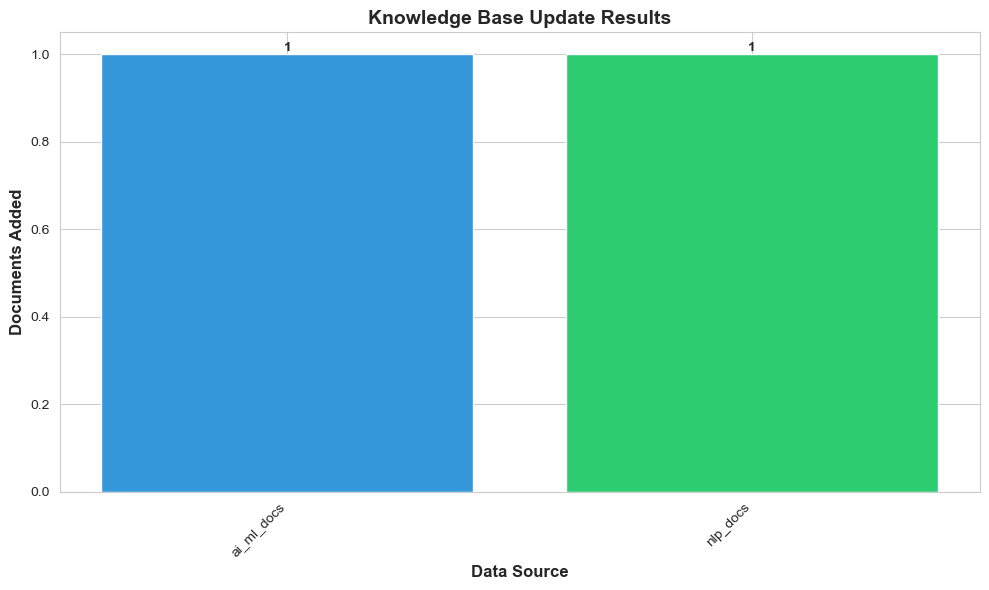

✅ Visualization saved!


In [6]:
source_names = [r['source_id'] for r in results]
docs_added = [r['documents_added'] for r in results]

plt.figure(figsize=(10, 6))
bars = plt.bar(source_names, docs_added, color=['#3498db', '#2ecc71'])
plt.xlabel('Data Source', fontsize=12, fontweight='bold')
plt.ylabel('Documents Added', fontsize=12, fontweight='bold')
plt.title('Knowledge Base Update Results', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('./demo_data/update_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved!")

In [7]:
test_queries = [
    "What is machine learning?",
    "Explain natural language processing"
]

print("\nTesting Knowledge Retrieval:\n" + "="*60)

for query in test_queries:
    print(f"\nQuery: {query}")
    print("-" * 60)
    
    query_embedding = embedding_service.generate_embedding(query)
    results_query = vector_db.query(
        collection_name="demo_knowledge_base",
        query_embedding=query_embedding,
        top_k=2
    )
    
    for i, (doc, distance) in enumerate(zip(results_query['documents'], 
                                            results_query['distances']), 1):
        similarity = 1 - distance
        print(f"\nResult {i} (Similarity: {similarity:.3f}):")
        print(f"{doc[:150]}...")

print("\n✅ Knowledge retrieval test complete!")

INFO:shared.vector_db_manager:🔍 Found 2 results in 'demo_knowledge_base'
INFO:shared.vector_db_manager:🔍 Found 2 results in 'demo_knowledge_base'



Testing Knowledge Retrieval:

Query: What is machine learning?
------------------------------------------------------------

Result 1 (Similarity: 0.432):
Machine Learning Fundamentals Machine learning is a subset of artificial intelligence that enables systems to learn from experience. Deep Learning use...

Result 2 (Similarity: -0.276):
Natural Language Processing NLP helps computers understand and manipulate human language. Text Classification assigns categories to text based on cont...

Query: Explain natural language processing
------------------------------------------------------------

Result 1 (Similarity: 0.301):
Natural Language Processing NLP helps computers understand and manipulate human language. Text Classification assigns categories to text based on cont...

Result 2 (Similarity: -0.337):
Machine Learning Fundamentals Machine learning is a subset of artificial intelligence that enables systems to learn from experience. Deep Learning use...

✅ Knowledge retrieval test 

In [8]:
update_logs = updater.get_update_logs(limit=10)

if update_logs:
    df = pd.DataFrame(update_logs)
    
    print("\nPerformance Metrics:")
    print("="*60)
    print(f"Total Updates: {len(df)}")
    print(f"Total Documents: {df['documents_added'].sum()}")
    print(f"Avg Time per Update: {df['elapsed_time'].mean():.2f}s")
    print(f"Success Rate: {(df['success'].sum() / len(df) * 100):.1f}%")
    print("="*60)


Performance Metrics:
Total Updates: 2
Total Documents: 2
Avg Time per Update: 0.16s
Success Rate: 100.0%


In [9]:
print("\n" + "="*60)
print("TASK 1: DYNAMIC KNOWLEDGE BASE EXPANSION - COMPLETE!")
print("="*60)
print("\n✅ Key Achievements:")
print("   - Automatic knowledge expansion")
print("   - Multiple data source support")
print("   - Efficient batch processing")
print("   - Complete logging and monitoring")
print("\n🎉 SUCCESS!")


TASK 1: DYNAMIC KNOWLEDGE BASE EXPANSION - COMPLETE!

✅ Key Achievements:
   - Automatic knowledge expansion
   - Multiple data source support
   - Efficient batch processing
   - Complete logging and monitoring

🎉 SUCCESS!
